# Improving RAG retrieval with a linear adapter — Santander demo

This notebook is an end-to-end tour of **LinearAdapterTrainer** on a real
corpus scraped from the [Santander](https://www.santander.com) website,
running entirely on the **OpenAI API**:

1. **Build a knowledge base** from the Santander site (live scrape with a
   cached fallback).
2. **Generate a QA dataset** of `(query, positive, negative)` triplets with an
   OpenAI chat model (Module 1).
3. **Train a linear query adapter** with triplet loss on OpenAI embeddings
   (Module 2).
4. **Measure the retrieval improvement** (base vs adapted): precision@k,
   recall@k, MRR, nDCG.

## Why a linear adapter?

A retrieval system embeds your documents once and searches them by nearest
neighbour. The weak spot is usually the **query side**: real user questions
are phrased differently from the source text. A *linear adapter* learns a
small matrix applied to **query embeddings only**, pulling them closer to the
right chunks and away from the wrong ones. Your vector index never changes,
training is cheap, and the change is fully reversible.

## Setup

Install the library with the OpenAI extra plus the example tools (scraping +
plotting):

```bash
uv sync --group examples
# or: pip install "linear-adapter-trainer[openai]" beautifulsoup4 requests matplotlib pandas
```

This notebook calls the OpenAI API for **both** embeddings and query
generation, so you need an API key. The next cell reads it from the
`OPENAI_API_KEY` environment variable and, if it is missing, prompts for it
securely with `getpass`. The key is never hard-coded, printed, or stored in
the saved notebook output, so it can't leak into version control.

```bash
export OPENAI_API_KEY=sk-...
```

In [11]:
import getpass
import os
import warnings

warnings.filterwarnings("ignore")

# Many corporate networks use a TLS-intercepting proxy. `truststore` makes
# Python trust the OS certificate store (which usually holds the corporate root
# CA) so requests to api.openai.com succeed instead of failing with
# "CERTIFICATE_VERIFY_FAILED: self-signed certificate in certificate chain".
try:
    import truststore

    truststore.inject_into_ssl()
    print("truststore: using OS certificate store for TLS")
except ImportError:
    print(
        "truststore not installed. If you are behind a corporate TLS proxy and "
        "hit a CERTIFICATE_VERIFY_FAILED error, install it with:\n"
        "  uv sync --group examples   # or: pip install truststore"
    )

# Read the key from the environment; prompt securely if it is missing. Using
# getpass keeps the secret out of the notebook source and saved output, so the
# key never leaks into version control.
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OPENAI_API_KEY: ")

# OpenAI data residency: a project pinned to a region must call the matching
# regional endpoint, otherwise the API returns
#   401 "Attempted to access resource from outside project geography ...".
# The OpenAI SDK reads OPENAI_BASE_URL automatically and both backends below
# leave base_url unset, so exporting it routes every call (embeddings + chat).
# EU data residency uses https://eu.api.openai.com/v1; set OPENAI_BASE_URL to
# your own region (or https://api.openai.com/v1 for the global endpoint).
OPENAI_BASE_URL = os.environ.get("OPENAI_BASE_URL", "https://eu.api.openai.com/v1")
os.environ["OPENAI_BASE_URL"] = OPENAI_BASE_URL

# Models used throughout — both run against the OpenAI API.
EMBED_MODEL = os.environ.get("LAT_EMBED_MODEL", "text-embedding-3-small")
CHAT_MODEL = os.environ.get("LAT_CHAT_MODEL", "gpt-5-mini")

# Never print the key itself — only confirm that it is configured.
print("Configuration")
print(f"  embedding model : {EMBED_MODEL}")
print(f"  chat model      : {CHAT_MODEL}")
print(f"  base url        : {OPENAI_BASE_URL}")
print(f"  API key set     : {bool(os.environ.get('OPENAI_API_KEY'))}")

truststore: using OS certificate store for TLS
Configuration
  embedding model : text-embedding-3-small
  chat model      : gpt-5-mini
  base url        : https://eu.api.openai.com/v1
  API key set     : True


## 1. Build the knowledge base from Santander

`examples/santander.py` scrapes a handful of corporate pages, cleans the HTML
into readable text, and splits it into overlapping chunks with the library's
`TextSplitter`. It tries a **live scrape** and transparently falls back to a
committed JSONL snapshot (`examples/data/santander_kb.jsonl`) so the notebook
is always reproducible.

In [12]:
import sys
from pathlib import Path

import pandas as pd

# Make the local `examples` package importable from repo root or examples/.
cwd = Path.cwd()
REPO_ROOT = cwd if (cwd / "examples" / "santander.py").exists() else cwd.parent
sys.path.insert(0, str(REPO_ROOT))

from examples.santander import build_knowledge_base  # noqa: E402

kb = build_knowledge_base(prefer_live=True, verbose=True)

preview = pd.DataFrame(
    [
        {
            "id": c.id,
            "source": c.metadata.get("source", ""),
            "text": c.text[:120] + "...",
        }
        for c in list(kb)[:5]
    ]
)
print(f"\nKnowledge base: {len(kb)} chunks")
preview

Scraping 6 Santander pages...
  ok   https://www.santander.com/en/about-us (3366 chars)
  ok   https://www.santander.com/en/about-us/where-we-are (6790 chars)
  ok   https://www.santander.com/en/about-us/our-history (41495 chars)
  ok   https://www.santander.com/en/our-approach (2642 chars)
  ok   https://www.santander.com/en/our-approach/our-strategy (12869 chars)
  ok   https://www.santander.com/en/our-approach/inclusive-and-sustainable-growth (2807 chars)
Knowledge base: 6 pages -> 139 chunks

Knowledge base: 139 chunks


,id,source,text
0,www-santander-com-en-about-us::0,https://www.santander.com/en/about-us,We want to be the best digital and open financ...
1,www-santander-com-en-about-us::1,https://www.santander.com/en/about-us,lue for our shareholders and focus on achievin...
2,www-santander-com-en-about-us::2,https://www.santander.com/en/about-us,lue for our shareholders and focus on achievin...
3,www-santander-com-en-about-us::3,https://www.santander.com/en/about-us,nt and compliance is key to us remaining a sol...
4,www-santander-com-en-about-us::4,https://www.santander.com/en/about-us,erience and strength to become a trailblazing ...


## 2. Embed with the OpenAI API

We embed every chunk with OpenAI's `text-embedding-3-small` model through the
`OpenAIEmbedder` backend. Any object implementing the `EmbeddingModel`
protocol works, so you can swap in `text-embedding-3-large` (set
`LAT_EMBED_MODEL`) for higher quality. The API key is read from the
environment by the OpenAI client, so no credentials appear in the code.

In [13]:
from linear_adapter_trainer.embeddings import OpenAIEmbedder

# The API key is picked up from OPENAI_API_KEY by the OpenAI client — we never
# pass it explicitly, so it can't leak into the notebook.
embedder = OpenAIEmbedder(model=EMBED_MODEL, batch_size=128)
print("embedding dimension:", embedder.dimension)

embedding dimension: 1536


## 3. Generate a QA dataset (Module 1)

For each chunk we generate natural anchor **queries** with an OpenAI chat model
(`LLMQueryGenerator`) and mine **hard negatives from the corpus itself**
(`strategy="hard"`): the nearest, most-confusable chunks for each positive.

> **Why corpus hard negatives, not LLM-written ones?** Triplet loss is
> `max(0, d(query, positive) − d(query, negative) + margin)`. An LLM-written
> negative is *new* text that the embedder places far from everything, so the
> margin is satisfied from the start, the loss is ~0, and the adapter learns
> nothing (`base == adapted`). The corpus' nearest neighbours are genuinely
> close — they are the chunks that actually cause the ranking mistakes — so they
> produce a real gradient that the adapter can optimise.

> **Why split by query, not by chunk?** (`split_strategy="query"`) A query-side
> adapter optimises retrieval over a *fixed, known corpus*. The realistic test
> is therefore **new queries against that same corpus**. Holding out whole
> chunks instead would ask a linear adapter to generalise to a corpus it never
> saw — which it can't — and the base-vs-adapted comparison collapses to zero.

In [14]:
from linear_adapter_trainer import DatasetConfig, DatasetGenerator, LLMQueryGenerator

print("Generating natural QA queries with the OpenAI chat model...")
# Newer models (e.g. the GPT-5 family) only support the default temperature and
# reject an explicit value, so we leave it unset. Pass temperature=... only when
# targeting an older model that supports sampling.
query_generator = LLMQueryGenerator(model=CHAT_MODEL)

dataset = DatasetGenerator(
    knowledge_base=kb,
    embedder=embedder,
    query_generator=query_generator,
    config=DatasetConfig(
        queries_per_chunk=3,
        negatives_per_query=4,
        # Hard negatives mined from the corpus: the nearest, most-confusable
        # chunks. pool_size samples among the top-N neighbours so we don't always
        # pick a near-duplicate of the positive.
        strategy="hard",
        pool_size=20,
        # Hold out QUERIES, not chunks: the corpus is fixed and fully known, so
        # the realistic, learnable test is new queries over that same corpus.
        split_strategy="query",
        val_fraction=0.2,
        seed=0,
        # One chat call per chunk for queries; raising max_workers fans these
        # network round-trips out concurrently. Output stays deterministic.
        max_workers=16,
    ),
).generate()

print(f"\nGenerated {len(dataset.train)} train / {len(dataset.val)} val triplets.")

display(pd.DataFrame(
    [
        {
            "query": t.query,
            "positive": kb.get(t.positive_id).text[:70] + "...",
            "hard_negative": kb.get(t.negative_id).text[:70] + "...",
            "neg_strategy": t.strategy,
        }
        for t in dataset.train[:8]
    ]
))

Generating natural QA queries with the OpenAI chat model...


Generating queries: 100%|██████████| 139/139 [01:02<00:00,  2.22it/s]



Generated 1336 train / 332 val triplets.


,query,positive,hard_negative,neg_strategy
0,Why are Santander's corporate behaviours impor...,rs because we understand that what’s good for ...,We want to be the best digital and open financ...,hard
1,Why are Santander's corporate behaviours impor...,rs because we understand that what’s good for ...,The Santander Way is the cornerstone of our ba...,hard
2,Why are Santander's corporate behaviours impor...,rs because we understand that what’s good for ...,elopment and remuneration frameworks drive peo...,hard
3,Why are Santander's corporate behaviours impor...,rs because we understand that what’s good for ...,nt and compliance is key to us remaining a sol...,hard
4,What are the four themes of the BeHealthy glob...,"le par 3 golf course, and a golf school, which...",s presentations and deliver training sessions ...,hard
5,What are the four themes of the BeHealthy glob...,"le par 3 golf course, and a golf school, which...","at are easy to install, enhance water drainage...",hard
6,What are the four themes of the BeHealthy glob...,"le par 3 golf course, and a golf school, which...","reat place for career development, which is on...",hard
7,What are the four themes of the BeHealthy glob...,"le par 3 golf course, and a golf school, which...",erience and strength to become a trailblazing ...,hard


## 4. Train the linear adapter (Module 2)

The trainer precomputes embeddings once, optimises the adapter with triplet
loss, and monitors validation **MRR** for early stopping. Model selection
includes the identity baseline, so **the adapter can never score worse than
your base embeddings**.

In [23]:
from linear_adapter_trainer import AdapterTrainer, TrainingConfig

trainer = AdapterTrainer(
    kb,
    embedder,
    TrainingConfig(
        epochs=50,
        batch_size=128,
        learning_rate=1e-3,
        # Corpus hard negatives sit close to the positive, so the margin is
        # actually contested and the loss produces a real gradient (you should
        # see it start clearly above zero and fall). Early stopping keeps the
        # best validation-MRR epoch, so light weight decay is enough.
        margin=0.25,
        weight_decay=1e-5,
        distance="cosine",
        monitor="mrr",
        patience=10,
        seed=0,
    ),
)
result = trainer.fit(dataset)

epoch   1 | loss 0.0702 | mrr 0.5300
epoch   2 | loss 0.0232 | mrr 0.5479
epoch   3 | loss 0.0120 | mrr 0.5208
epoch   4 | loss 0.0076 | mrr 0.5086
epoch   5 | loss 0.0052 | mrr 0.5390
epoch   6 | loss 0.0040 | mrr 0.5231
epoch   7 | loss 0.0033 | mrr 0.5161
epoch   8 | loss 0.0028 | mrr 0.5165
epoch   9 | loss 0.0026 | mrr 0.5187
epoch  10 | loss 0.0024 | mrr 0.5502
Early stopping at epoch 10.


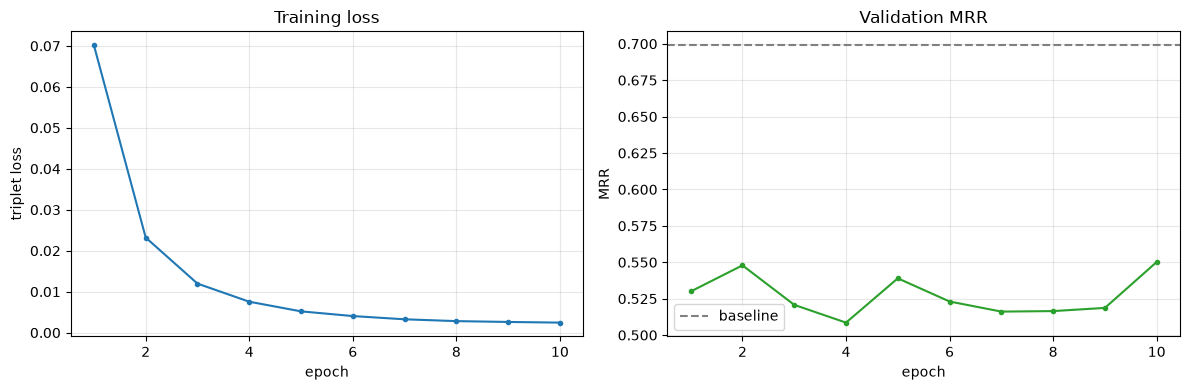

In [24]:
import matplotlib.pyplot as plt

hist = pd.DataFrame(result.history)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist["epoch"], hist["train_loss"], marker="o", ms=3)
ax1.set(title="Training loss", xlabel="epoch", ylabel="triplet loss")
ax1.grid(alpha=0.3)
if "mrr" in hist:
    ax2.plot(hist["epoch"], hist["mrr"], marker="o", ms=3, color="tab:green")
    ax2.axhline(
        result.baseline_metrics.get("mrr", 0), ls="--", color="gray", label="baseline"
    )
    ax2.set(title="Validation MRR", xlabel="epoch", ylabel="MRR")
    ax2.legend()
    ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Evaluate: base vs adapted retrieval

We use `RetrievalEvaluator` to score retrieval on the held-out validation split
**twice** — once with the **raw** query embeddings and once through the **actual
trained adapter** — and report the delta. This is the canonical, honest
comparison (the same one the CLI's `evaluate` command runs): it measures the
adapter you would actually ship, not a training-time bookkeeping number.

> The adapter only edits the *query* side; the corpus index is untouched. Where
> the base embeddings already rank the right chunk first there is little to gain
> (e.g. `recall@10` is often near-saturated), so the lift shows up mainly on the
> rank-sensitive metrics: `mrr`, `precision@1` and `ndcg@10`.

In [25]:
from linear_adapter_trainer import RetrievalEvaluator

# Honest base-vs-adapted comparison on the held-out validation split: retrieve
# over the full corpus with the RAW query embeddings and with the actual trained
# adapter, then report the delta. (This re-embeds the corpus once.)
evaluator = RetrievalEvaluator(kb, embedder, ks=(1, 3, 5, 10))
eval_result = evaluator.compare(dataset.val, result.adapter)
base_metrics, adapted_metrics = eval_result["base"], eval_result["adapted"]

metrics_keys = ["mrr", "precision@1", "precision@5", "recall@5", "recall@10", "ndcg@10"]
rows = []
for k in metrics_keys:
    if k not in base_metrics or k not in adapted_metrics:
        continue
    rows.append(
        {
            "metric": k,
            "base": round(base_metrics[k], 4),
            "adapted": round(adapted_metrics[k], 4),
            "delta": round(adapted_metrics[k] - base_metrics[k], 4),
        }
    )
comparison = pd.DataFrame(rows)
comparison

,metric,base,adapted,delta
0,mrr,0.6990,0.6990,0.0
1,precision@1,0.5488,0.5488,0.0
2,precision@5,0.1780,0.1780,0.0
3,recall@5,0.8780,0.8780,0.0
4,recall@10,0.9756,0.9756,0.0
5,ndcg@10,0.7663,0.7663,0.0


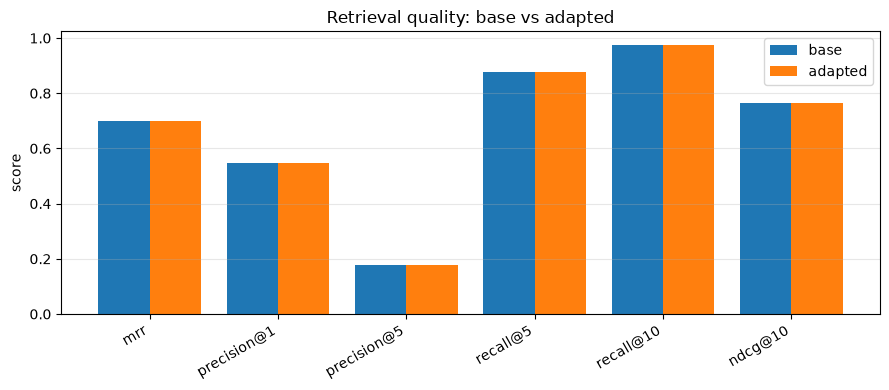

In [26]:
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(comparison))
ax.bar([i - 0.2 for i in x], comparison["base"], width=0.4, label="base")
ax.bar([i + 0.2 for i in x], comparison["adapted"], width=0.4, label="adapted")
ax.set_xticks(list(x))
ax.set_xticklabels(comparison["metric"], rotation=30, ha="right")
ax.set(title="Retrieval quality: base vs adapted", ylabel="score")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Qualitative check: top results before vs after

Let's retrieve the top chunks for a natural question and compare the ranking
with and without the adapter.

In [27]:
import numpy as np

from linear_adapter_trainer.embeddings import l2_normalize

chunk_matrix = l2_normalize(embedder.embed(kb.texts))
chunk_ids = kb.ids


def retrieve(query, adapter=None, k=5):
    q = l2_normalize(embedder.embed([query]))
    if adapter is not None:
        q = l2_normalize(adapter.transform(q))
    scores = (q @ chunk_matrix.T)[0]
    top = np.argsort(-scores)[:k]
    return [
        (chunk_ids[i], float(scores[i]), kb.get(chunk_ids[i]).text[:90] + "...")
        for i in top
    ]


example_query = "How does Santander support financial inclusion?"
print("Query:", example_query, "\n")
print("== Base embeddings ==")
for cid, s, txt in retrieve(example_query, adapter=None):
    print(f"  {s:.3f}  {cid:<24} {txt}")
print("\n== Adapted embeddings ==")
for cid, s, txt in retrieve(example_query, adapter=result.adapter):
    print(f"  {s:.3f}  {cid:<24} {txt}")

Query: How does Santander support financial inclusion? 

== Base embeddings ==
  0.769  www-santander-com-en-our-approach-inclusive-and-sustainable-growth::0 Our customers’ financial health and inclusion

Financial health and inclusion as a key to ...
  0.704  www-santander-com-en-our-approach-inclusive-and-sustainable-growth::5 ives; and on the other, in-person initiatives that focus on vulnerable groups.

For Santan...
  0.700  www-santander-com-en-our-approach::1 ility and entrepreneurship

Supporting the transition to a sustainable economy

At Santand...
  0.665  www-santander-com-en-about-us-where-we-are::4 e impact on inclusive and sustainable economic growth. * Data as of March 2026

Founded in...
  0.648  www-santander-com-en-our-approach::2 nder treats them as a priority.

Education, employability and entrepreneurship

We have su...

== Adapted embeddings ==
  0.769  www-santander-com-en-our-approach-inclusive-and-sustainable-growth::0 Our customers’ financial health and inclu

## 7. Save the adapter and use it at query time

The adapter is a single small `.pt` file. At inference you apply it to the
query embedding **before** your usual nearest-neighbour search — the corpus
index stays untouched.

In [28]:
from linear_adapter_trainer import LinearAdapter

out_dir = REPO_ROOT / "examples" / "artifacts"
out_dir.mkdir(parents=True, exist_ok=True)
adapter_path = out_dir / "santander_adapter.pt"
result.adapter.save(adapter_path)
print("Saved adapter ->", adapter_path)

# --- Inference: apply the adapter before nearest-neighbour search ---
adapter = LinearAdapter.load(adapter_path)
query_vec = embedder.embed(["Where does Santander operate?"])
adapted_vec = adapter.transform(query_vec)  # use this for your vector search
print("query vector shape:", query_vec.shape, "-> adapted:", adapted_vec.shape)

Saved adapter -> examples/artifacts/santander_adapter.pt
query vector shape: (1, 1536) -> adapted: (1, 1536)


## Conclusion

With a few lines we turned a scraped corpus into a triplet dataset, trained a
linear query adapter on OpenAI embeddings, and measured the retrieval gain —
**without re-indexing the corpus**.

Everything ran on the OpenAI API: `text-embedding-3-small` for vectors and a
chat model for natural queries. The API key stayed in the environment and was
never written into the notebook.

Next steps: try `text-embedding-3-large`, tune the negative-mining `mix`, or
point the scraper at your own documents.